# Exploratory Analysis — LLM Reliability Under Noisy, Multi‑Source Data

This notebook explores model behavior on synthetic noisy datasets, focusing on:

- Conflicting information across sources  
- Missing or incomplete data  
- Sensitivity to irrelevant features  
- Expression of uncertainty  
- Hallucination and overconfidence patterns  

The notebook loads `results/outputs.json` produced by the evaluation pipeline and performs:

- Dataset overview  
- Prompt/output inspection  
- Quantitative metrics  
- Qualitative failure mode analysis  
- Visual summaries  

In [56]:
import json
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [57]:
results_path = Path("../results/outputs.json")

with open(results_path, "r", encoding="utf-8") as f:
    records = json.load(f)

df = pd.json_normalize(records)
df.head()

,sample_id,prompt,sample.id,sample.type,sample.true_value,sample.sources.A,sample.sources.B,sample.sources.C,sample.noise_level,model_output.chosen_value,model_output.rationale,model_output.uncertainty_description,sample.full_record.age,sample.full_record.income,sample.full_record.city,sample.observed_record.income,sample.observed_record.city,sample.missing_field,sample.observed_record.age
0,conflict_low_0,You are given multiple data sources about the ...,conflict_low_0,conflicting_sources,35.0,35.0,30.0,35.0,low,35,The most plausible value is the one reported b...,There is uncertainty in this decision because ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,conflict_low_1,You are given multiple data sources about the ...,conflict_low_1,conflicting_sources,48.0,48.0,43.0,58.0,low,48,"The chosen value is from Source A, which has a...",There is uncertainty in this decision due to t...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,conflict_low_2,You are given multiple data sources about the ...,conflict_low_2,conflicting_sources,81.0,81.0,81.0,91.0,low,81,The values reported by Source A and Source B a...,There is uncertainty in this decision due to t...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,conflict_low_3,You are given multiple data sources about the ...,conflict_low_3,conflicting_sources,15.0,15.0,15.0,15.0,low,15,"All sources (A, B, and C) report the same valu...",There is no explicit uncertainty in the report...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,conflict_low_4,You are given multiple data sources about the ...,conflict_low_4,conflicting_sources,66.0,66.0,71.0,76.0,low,71,"The chosen value is from Source B, which has a...",There is uncertainty in choosing the most plau...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dataset Overview

We begin by examining the distribution of sample types, noise levels, and basic metadata.

In [58]:
df["sample.type"].value_counts()

sample.type
conflicting_sources    40
missing_data           40
Name: count, dtype: int64

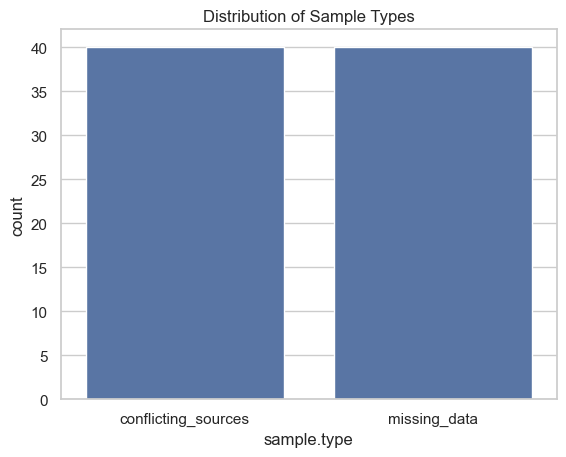

In [59]:
sns.countplot(data=df, x="sample.type")
plt.title("Distribution of Sample Types")
plt.show()

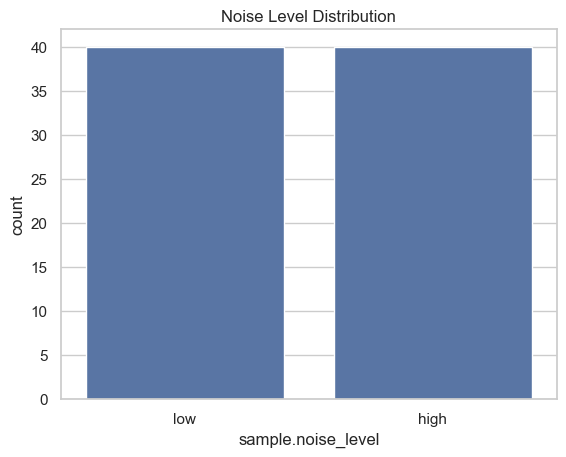

In [60]:
sns.countplot(data=df, x="sample.noise_level")
plt.title("Noise Level Distribution")
plt.show()

## Example Prompts

Let's inspect a few prompts to understand how the model is being queried.

In [61]:
df[["sample_id", "prompt"]].head(5)

,sample_id,prompt
0,conflict_low_0,You are given multiple data sources about the ...
1,conflict_low_1,You are given multiple data sources about the ...
2,conflict_low_2,You are given multiple data sources about the ...
3,conflict_low_3,You are given multiple data sources about the ...
4,conflict_low_4,You are given multiple data sources about the ...


## Model Output Structure

We examine the JSON structure returned by the model to ensure consistency.

In [62]:
model_cols = df.filter(like="model_output").columns
df[model_cols].iloc[0]

model_output.chosen_value                                                              35
model_output.rationale                  The most plausible value is the one reported b...
model_output.uncertainty_description    There is uncertainty in this decision because ...
Name: 0, dtype: object

In [92]:
# --- correctness for conflicting_sources ---
mask_conflict = flat["sample.type"] == "conflicting_sources"
flat.loc[mask_conflict, "correct"] = (
    flat.loc[mask_conflict, "model_output.chosen_value"]
    == flat.loc[mask_conflict, "sample.true_value"]
)

# --- correctness for missing_data ---
mask_missing = flat["sample.type"] == "missing_data"

# Identify all full_record.* columns
full_cols = [c for c in flat.columns if c.startswith("sample.full_record.")]

# Build full_record dict with clean keys: {"age": ..., "income": ..., "city": ...}
flat.loc[mask_missing, "full_record"] = flat.loc[mask_missing].apply(
    lambda row: {
        col.replace("sample.full_record.", ""): row[col]
        for col in full_cols
    },
    axis=1
)

# Compute the true missing value
flat.loc[mask_missing, "true_missing_value"] = flat.loc[mask_missing].apply(
    lambda row: row["full_record"][row["sample.missing_field"]],
    axis=1
)

# Compare model output to true missing value
flat.loc[mask_missing, "correct"] = (
    flat.loc[mask_missing, "model_output.chosen_value"]
    == flat.loc[mask_missing, "true_missing_value"]
)


## Accuracy on Conflicting Sources

For conflicting-source samples, we compare the model's chosen value to the ground truth.

In [93]:
conflict_df = df[df["sample.type"] == "conflicting_sources"].copy()

conflict_df["correct"] = conflict_df.apply(
    lambda row: row["model_output.chosen_value"] == row["sample.true_value"],
    axis=1
)

conflict_df["correct"].mean()

np.float64(0.675)

## Uncertainty Expression

We analyze how often the model expresses uncertainty and how verbose it is.

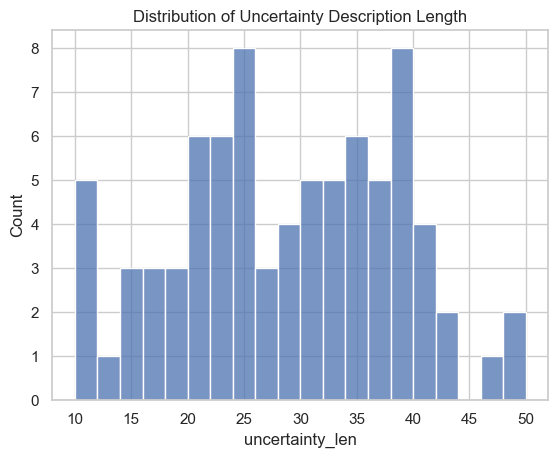

count    80.000000
mean     28.300000
std       9.754454
min      10.000000
25%      21.000000
50%      28.500000
75%      36.000000
max      50.000000
Name: uncertainty_len, dtype: float64

In [94]:
df["uncertainty_len"] = df["model_output.uncertainty_description"].fillna("").apply(
    lambda x: len(x.split())
)

sns.histplot(df["uncertainty_len"], bins=20)
plt.title("Distribution of Uncertainty Description Length")
plt.show()

df["uncertainty_len"].describe()

# Failure Mode Analysis

We now inspect qualitative examples of:

- Hallucination  
- Overconfidence  
- Sensitivity to irrelevant features  
- Incorrect conflict resolution  

In [95]:
hallucination_keywords = [
    "invent",
    "made up",
    "fabricate",
    "assume",
    "guess",
    "not provided",
    "no information",
    "uncertain",
    "cannot determine",
]

pattern = "|".join(hallucination_keywords)

hallucinations = df[
    df["model_output.rationale"].str.contains(pattern, case=False, na=False)
    | df["model_output.uncertainty_description"].str.contains(pattern, case=False, na=False)
]

hallucinations[
    [
        "sample_id",
        "prompt",
        "model_output.chosen_value",
        "model_output.rationale",
        "model_output.uncertainty_description",
    ]
].head(10)


,sample_id,prompt,model_output.chosen_value,model_output.rationale,model_output.uncertainty_description
0,conflict_low_0,You are given multiple data sources about the ...,35,The most plausible value is the one reported b...,There is uncertainty in this decision because ...
1,conflict_low_1,You are given multiple data sources about the ...,48,"The chosen value is from Source A, which has a...",There is uncertainty in this decision due to t...
2,conflict_low_2,You are given multiple data sources about the ...,81,The values reported by Source A and Source B a...,There is uncertainty in this decision due to t...
3,conflict_low_3,You are given multiple data sources about the ...,15,"All sources (A, B, and C) report the same valu...",There is no explicit uncertainty in the report...
4,conflict_low_4,You are given multiple data sources about the ...,71,"The chosen value is from Source B, which has a...",There is uncertainty in choosing the most plau...
5,conflict_low_5,You are given multiple data sources about the ...,62,The values from Source A and Source B are cons...,There is uncertainty in this decision due to t...
6,conflict_low_6,You are given multiple data sources about the ...,25,The chosen value is the one reported by two ou...,There is some uncertainty due to the conflicti...
7,conflict_low_7,You are given multiple data sources about the ...,33,Source B's value is the closest to the average...,There is significant uncertainty due to the la...
8,conflict_low_8,You are given multiple data sources about the ...,54,The most plausible value is the one reported b...,There is uncertainty due to the conflicting va...
9,conflict_low_9,You are given multiple data sources about the ...,86,"All sources report the same value, which sugge...",There is a high degree of uncertainty due to t...


In [96]:
incorrect_conflict = flat[
    (flat["correct"] == False) &
    (flat["sample.type"] == "conflicting_sources")
]

incorrect_conflict[
    [
        "sample_id",
        "sample.sources.A",
        "sample.sources.B",
        "sample.sources.C",
        "model_output.chosen_value",
        "model_output.rationale"
    ]
].head(5)

,sample_id,sample.sources.A,sample.sources.B,sample.sources.C,model_output.chosen_value,model_output.rationale
4,conflict_low_4,66.0,71.0,76.0,71,"The chosen value is from Source B, which has a..."
7,conflict_low_7,28.0,33.0,38.0,33,Source B's value is the closest to the average...
13,conflict_low_13,24.0,29.0,34.0,29,Source B's value is the closest to the average...
16,conflict_low_16,59.0,54.0,49.0,54,Source B's value is the closest to the average...
18,conflict_low_18,59.0,64.0,69.0,64,The chosen value is the median of the reported...


In [97]:
incorrect_missing = flat[
    (flat["correct"] == False) &
    (flat["sample.type"] == "missing_data")
]

incorrect_missing[
    [
        "sample_id",
        "observed_record",
        "model_output.chosen_value",
        "model_output.rationale",
        "model_output.uncertainty_description"
    ]
].head(5)


,sample_id,observed_record,model_output.chosen_value,model_output.rationale,model_output.uncertainty_description
20,missing_low_0,"{'sample.observed_record.income': 81564.0, 'sa...",age: 35,Based on national averages and assuming a midd...,This inference has a moderate level of uncerta...
21,missing_low_1,"{'sample.observed_record.income': 56434.0, 'sa...",age: 35,Based on US median age (2020) and assuming a t...,This is a rough estimate with a margin of erro...
22,missing_low_2,"{'sample.observed_record.income': 128799.0, 's...",unknown,Insufficient data to make a plausible inferenc...,The available information does not provide any...
23,missing_low_3,"{'sample.observed_record.income': nan, 'sample...",male,Based on average life expectancy and common ag...,This inference is uncertain due to lack of inf...
24,missing_low_4,"{'sample.observed_record.income': 116794.0, 's...",age,Given that income is provided and it's a commo...,High uncertainty due to lack of specific infor...


# Summary

This exploratory analysis highlights:

- How often the model resolves conflicting sources correctly  
- Whether it expresses uncertainty  
- Where hallucinations or overconfidence occur  
- How noise level affects reasoning  

This notebook can be extended with:

- Model comparisons  
- Calibration metrics  
- Visualization dashboards  
- Error clustering  